# Assignment 1
# Hash Tables and Hash Functions     
## CSCI E-108
### Steve Elston

## Introduction

The ability to operate on massive datasets is a distinguishing characteristic of mining algorithms. **Hashing and Key-Value Pairs:** Large scale data is typically managed using key-value (KV) pairs in hash tables. The exercises in this assignment give you some experience working with KV pair data management in a hash table.  

In order to keep the scope of this assignment manageable and to demonstrate core principles, you will use limited versions of KV pair management on a hash table. Specifically, you will use a simple Python list implement these concepts rather than dedicated large scale analytic platforms. 


> **Instructions:** For this assignment you will complete the exercises shown. All exercises involve creating and executing some Python code. Additionally, most exercises have questions for you to answer. You can answer questions by creating a Markdown cell and writing your answer. If you are not familiar with Markdown, you can find documentation and a brief tutorial [here](https://jupyter-notebook.readthedocs.io/en/stable/examples/Notebook/Working%20With%20Markdown%20Cells.html).
> 
> When you have completed the exercises, upload your completed notebook to Canvas.  

To get started, execute the code in the cell below to load the required packages. 

In [36]:
import pandas as pd
import numpy as np
import numpy.random as nr
from scipy.stats import ttest_ind, f_oneway
from itertools import product, combinations
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import comb
import math
import time
import sys

pd.set_option("display.max_rows", None, "display.max_columns", None)

## Synthetic Data for Multiple Hypothesis Testing

Testing multiple hypothesis in high-dimensional data is problematic. Exhaustively testing all pairwise relationships between variables in a data set is a commonly used, but generally misleading, form of **multiple comparisons**. The chance of finding false significance, using such a **data dredging** approach, can be surprisingly high. 

In the following exercises you will perform multiple comparisons on **20 identically distributed independent (iid)** variables. Ideally, such tests should not find significant relationships, but the actual result is quite different. Here we create a synthetic data set with 20 iid Normal variables of 1000 samples each. Execute the code in the cell below to compute this data by random sampling and display the mean and variance of each variable and the correlation between them.  

The means of the variables are
 [-0.00021802 -0.02469621 -0.04590329 -0.03378607  0.04803816 -0.0483221
  0.00823324  0.07504879 -0.02464511  0.02506955  0.01587333 -0.02779571
  0.0283405  -0.007355   -0.01933494  0.04458928 -0.04394166  0.04176807
  0.04012348  0.03759568]

The variances of the variables are
 [0.99858704 1.1399064  0.99541705 1.03581236 0.99903254 0.98047187
 0.9430031  1.0229532  1.04648727 0.97117199 0.91340712 0.96426648
 1.06103587 0.98162457 1.01358424 1.05532882 0.99885087 0.92218934
 0.96236408 1.04297434]


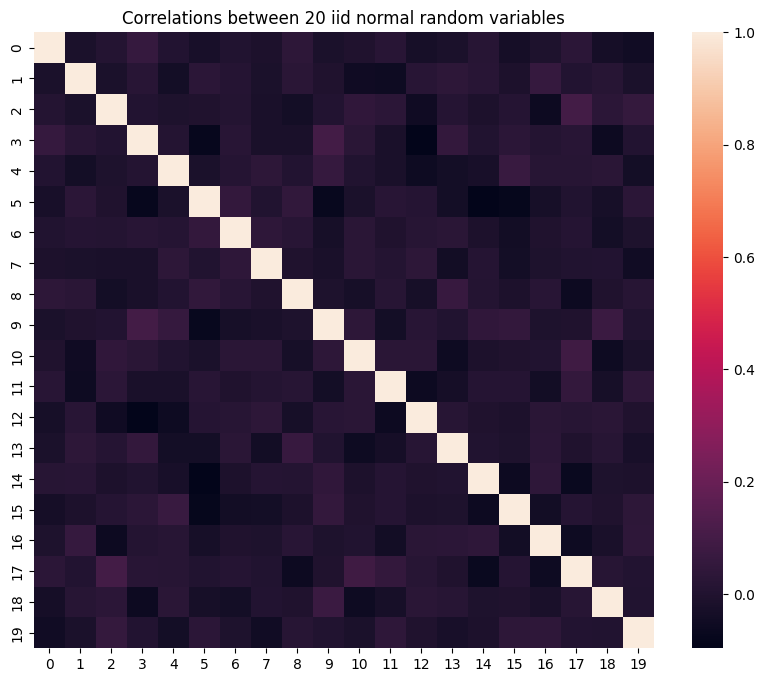

In [37]:
ncolumns = 20
nr.seed(22349)
normal_vars = nr.normal(size=(1000,ncolumns))
print('The means of the variables are\n', np.mean(normal_vars, axis = 0))
print('\nThe variances of the variables are\n', np.var(normal_vars, axis = 0))

_, ax = plt.subplots(figsize=(10,8))
sns.heatmap(np.corrcoef(np.transpose(normal_vars)), ax=ax);
ax.set_title('Correlations between 20 iid normal random variables');

Notice that means are close to 0.0 and variances are close to 1.0 respectively.    



## Hash Functions and Hash Tables  

Management of massive datasets requires using **key-value pairs** in a **hash table**. The keys are hashed and the hashes used as indices to reference buckets in the hash table. The buckets hold a tuple of the original key (unhashed) and the values.   
 
The question is, how can we create a good hash function for the the keys? Ideally, the hash function should produce keys with these closely related properties:   
1. The hash values should be unique given the keys to avoid hash collisions.
2. The hash values should be uniformly distributed given the keys to minimize the probability of collisions.

> **Note:** The following exercises are intended to demonstrate the principles of working with hash functions and hash tables. It will be clear that we could use a Pandas or Polars data frame for the multiple comparisons calculations. After all, there are only 190 possible pairs, given the $n=20$ vectors.
> $$N_{pairs} = n(n-1) = 190$$
> But using packages like Pandas and Polars hides the details of hashing that we are interested in here.  

### A simple hash functions
We will start by using a fairly simple, easy to implement and easy to understand hash function that has generally good properties. Consider hashing a set of integers, $U = [i_1, i_2, i_3,..., u_u]$. We want to create a family of hash functions, $H(U) \rightarrow m$, to map $U$ to $m$ unique hash values. Ideally, we want the the probability of a hash value to be uniform, $p \big(h(i) \big) \le \frac{1}{m}$.    

For the integer keys, we will work work with a universal hash function in the form:     

$$h(i) = \big( (a\ i + b)\ mod\ p \big)\ mod\ m$$
where   
- a is a random multiplier, $0 \lt a \lt p -1$ and $a \ne 0$.
- b is a random additive factor, .   
- p is a (usually prime) number, $p \ge |U|$, $|U| = $ size for the set to be hashed.
- m is the size of the hash table.

In this case, we will be working with a vector of keys of length 2, $K=[k_1,k_2]$. The hash of an $n$ length vector of values can easily be computed:    

$$h(K) = \Big( \sum^n_{i=1} h_i (k_i) \Big)\ mod\ m$$
Where, each of the $h_1, h_2, ..., h_n$ are independent universal hash functions.   

> **Exercise 1-1:** In this notebook you will perform pairwise hypothesis tests on sets of vector-valued variables. There are $\frac{n (n-1)}{2}$ pairwise combinations. There are two keys, $[i,j]$, for this hash table.
> 
> We could simply manage the results set in a Pandas data frame and do not need a sophisticated and scaleable hash table. To fulfill one of the goals of these exercises, we will use a hash table with vector-valued keys.     
>
> In this exercise you will test a universal hash function using vector-valued keys. To complete the code and test this hash, do the following:    
> 1. Complete `hash_function` in the code cell below to implement the integer key universal hash function discussed the foregoing section. The function should return an integer hash in the range $[1,1024]$ given an integer key value. 
> 2. Complete the code that iterates over all combinations of the keys (indexes) of the 20 variables and displays the keys and hash values.
>    - Use the itertools package [combinations](https://docs.python.org/3/library/itertools.html#itertools.combinations) function to find all combinations of two keys in `range(ncolumns)`.
>    - For each combination of keys, $i, j$, find the hash value using the `multivariate_hash` function provided.
>    - Append the keys and hash value to `hash_list`.
> Execute your code and examine the results. 

In [38]:
modulo=1024
a_s=[10147, 34519]
b_s=[2341, 7575]
p_s=[101273, 106949]   

def hash_function(key, a, b, p, modulo):
    """
    Function to compute hash for hash of x 

    Args: 
        x - integer value to be hashed 
        a - random multiplier value
        b - random addition value 
        p - random modulo value
        modulo - an integer = length of the hash table 

    Returns: a integer hash value     
    """
    return int((((a * key + b) % p) % modulo) + 1)
      

def multivariate_hash(x, a, b, p, modulo): 
    """
    Function to compute hash for hash a vector x 

    Args: 
        x - vector or list of integer values 
        a - random vector of multiplier values of len(x)
        b - random vector of addition values of len(x) 
        p - random vector of modulo values of len(x) 
        modulo - an integer = length of the hash table 

    Returns: a integer hash value     
    """
    h = []
    for i, key in enumerate(x):
        h.append(hash_function(key, a[i], b[i], p[i], modulo))
    return sum(h) % modulo


hash_list = []
## Put your code below
for i, j in combinations(range(ncolumns), 2):
    hash_value = multivariate_hash([i, j], a_s, b_s, p_s, modulo)
    hash_list.append((i, j, hash_value))

    ## Print a sample of the hash values 
    if i <= 3:             
        print('i = ' + str(i) + '  j = ' + str(j) + '   hash = ' + str(hash_value))
     

i = 0  j = 1   hash = 405
i = 0  j = 2   hash = 108
i = 0  j = 3   hash = 382
i = 0  j = 4   hash = 85
i = 0  j = 5   hash = 812
i = 0  j = 6   hash = 62
i = 0  j = 7   hash = 789
i = 0  j = 8   hash = 492
i = 0  j = 9   hash = 195
i = 0  j = 10   hash = 469
i = 0  j = 11   hash = 172
i = 0  j = 12   hash = 899
i = 0  j = 13   hash = 149
i = 0  j = 14   hash = 876
i = 0  j = 15   hash = 579
i = 0  j = 16   hash = 853
i = 0  j = 17   hash = 556
i = 0  j = 18   hash = 259
i = 0  j = 19   hash = 533
i = 1  j = 2   hash = 15
i = 1  j = 3   hash = 289
i = 1  j = 4   hash = 1016
i = 1  j = 5   hash = 719
i = 1  j = 6   hash = 993
i = 1  j = 7   hash = 696
i = 1  j = 8   hash = 399
i = 1  j = 9   hash = 102
i = 1  j = 10   hash = 376
i = 1  j = 11   hash = 79
i = 1  j = 12   hash = 806
i = 1  j = 13   hash = 56
i = 1  j = 14   hash = 783
i = 1  j = 15   hash = 486
i = 1  j = 16   hash = 760
i = 1  j = 17   hash = 463
i = 1  j = 18   hash = 166
i = 1  j = 19   hash = 440
i = 2  j = 3   hash = 

> 3. The next question is how good is this hash function. We can run a simple test by plotting the hash values computed. Execute the code in the cell below to display a histogram and a cumulative distribution plot of the hash values. 

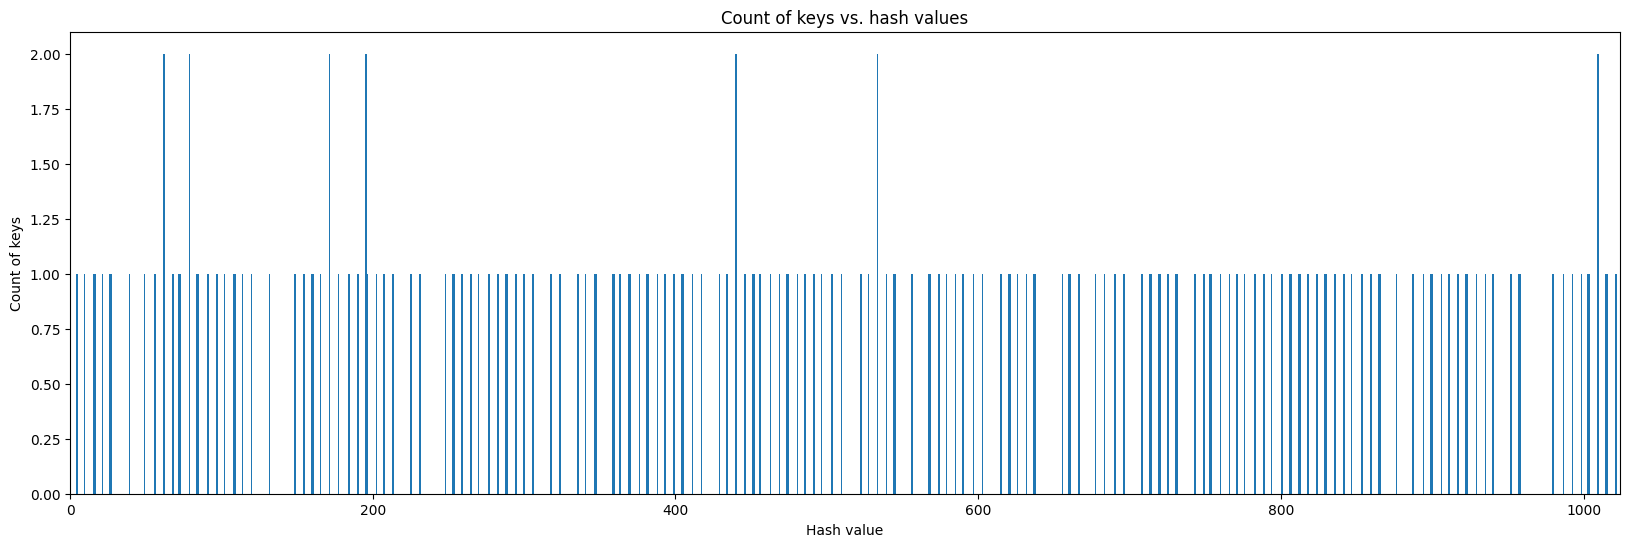

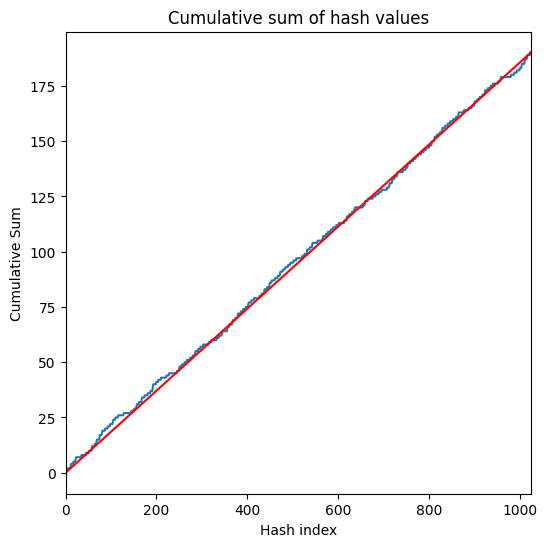

In [39]:
def plot_hash(hashes, bins=1024, modulo=1024):
    fig, ax = plt.subplots(figsize=(20, 6))
    counts, bins, _ = ax.hist(hashes, bins=bins);
    ax.set_ylabel('Count of keys');
    ax.set_xlabel('Hash value');
    ax.set_title('Count of keys vs. hash values');
    ax.set_xlim(0.0, modulo)
    plt.show();

    fig, ax = plt.subplots(figsize=(6,6))
    ax.plot(range(len(counts)), np.cumsum(counts))
    ax.plot([0.0,len(counts)], [0.0,len(hashes)], color='red');
    ax.set_ylabel('Cumulative Sum');
    ax.set_xlabel('Hash index');
    ax.set_title('Cumulative sum of hash values');
    ax.set_xlim(0.0, modulo)
    plt.show();

hash_values = [x[2] for x in hash_list] # added this because of dimensionality error, previous hash list was (i,j,hash_value) tuples
plot_hash(hash_values)    

> Examine these results and answer the following questions in one or two sentence.
> 1. Are hash collisions evident?     
> 2. Based on the histogram and cumulative distribution plot does this hash function have nearly ideal behavior, and what deviations can you observe?
> 3. Hypothetically, we could reduce the number of hash collisions by using a longer hash table. For massive scale problems why is this approach not practical?  
> **End of exercise.**

> **Answers:**    
> 1. Yes, a few hash collisions are evident, as one can see in the histogram where some hash buckets have a count of two.    
> 2. The hash function has nearly ideal behaviour, as the hash values are spread evenly accross the hash table and cumulative distribution is close to an ideal straight line (as in: the red line). The main deviation are small local gaps, clusters and a few collisions.    
> 3. We can use a longer hash table for a reduction of collisions. This is impractical for massive scale problems, as it would require much more memory and storage, while many buckets would remain unused.

### Linear probing        

Given the inevitable hash collisions we need a method to resolve them. **[Linear probing](https://en.wikipedia.org/wiki/Linear_probing)** is an effective, efficient and widely used hash collision resolution algorithm. The basic ideas is simple. If a hash bucket is occupied the algorithm linearly scans the table until an open bucket is found. The keys in each bucket are then used for look-ups.   

**Complexity of Linear Probing**       

The complexity of the linear probing algorithm increases as the fraction of buckets occupied increases.      


> **Exercise 1-2:** You will now investigate how collision probability and complexity of linear probing increases as the occupancy of a hash table increases. Complete and execute the code in the cell below.
> 1. Use the Numpy linspace function to compute an array of the load factor with 100 values in the interval $[0.1, 0.9]$.
> 2. Compute a list of the expected number of probs given the load factor values.        

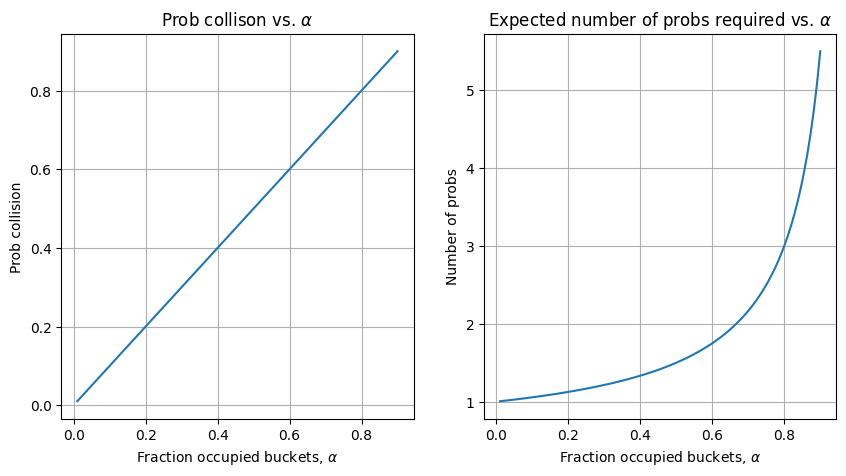

In [40]:
## Create a Numpy array of load factor or probability  
## of collision in the range [0.01, 0.90]  
alpha = np.linspace(0.01, 0.9, 100)

## Compute a list of the expected number of probs given
## a load factor, alpha
n_probs = [1 + 0.5*(alpha_x/(1-alpha_x)) for alpha_x in alpha]

## Display the 
_, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].plot(alpha, alpha);
ax[0].set_xlabel(r'Fraction occupied buckets, $\alpha$');
ax[0].set_ylabel('Prob collision');
ax[0].set_title(r'Prob collison vs. $\alpha$');
ax[0].grid();

ax[1].plot(alpha, n_probs);
ax[1].set_xlabel(r'Fraction occupied buckets, $\alpha$');
ax[1].set_ylabel('Number of probs');
ax[1].set_title(r'Expected number of probs required vs. $\alpha$');
ax[1].grid();



> Now, answer the following questions in one or two sentences.
> 1. Describe the implications and relationship between the hash table load factor and probability of implications.     
> 2. Describe the implications and relationship between the hash table load factor and expected prob complexity.      
> 3. Say that you wish to limit prob complexity to less than about 1.5, or a expected number of probs is 1.5 per hash operation. What is the approximate maximum load factor for the table? 

> **Answers:**
> 1. As the hash table load factor increases, the probability of a collision also increases. In this model, the collision probability is approximately equal to the fraction of occupied buckets.       
> 2. The expected probing complexity increases slowly at low load factors but very fast at high load factors. This means linear probing is efficient when the table is relatively sparse, but becomes increasingly expensive as the load factor nears 1.    
> 3. To keep the expected number of probes below about 1.5, the maximum load factor should be approximately 0.5.       

**A simple linear probing algorithm**

The linear probing algorithm is conceptually simple. The prob tests the bucket index by the hash computed from the key. If the bucket is empty. the prob process terminates. If the buck is filled, the prob sequentially probs subsequent buckets in order until a empty bucket is found. In detail, the flow of this function is:  
1. The bucket of the hashed key value is tested to see if it is empty. **Complete the code required for this case to add the key-value tuple to the table.**
2. If the first bucket is used, the linear probing starts with a while statement. The loop continues until an empty bucket is found or no empty bucket is available.
    - The hash value is incremented by 1.
    - If the new hash value is greater than the table length the hash value is set to 0, the beginning of the table. If the flag showing the table has started from the beginning already, the function returns `None` since there are no open hash buckets and prints an error message. Otherwise, the flag is set to 1 and probing for an open bucket continues.
3. Once the correct bucket is found, the value is inserted into the table and the table is returned.   

> **Exercise 1-3:** You will now complete and execute the code to implement a simple linear probing algorithm.   

In [41]:
def instantiate_hash(length):  
    """
    function instantiates a hash table of lenght 'length'
    """
    return [None]*length
   

def linear_probing_insert(hash_value, kv_pair, hash_table):   
    """
    Function to insert key-value pairs into an existing hash table 

    Args
        hash_value - the hash index, int
        kv_pair - the k-v pair to inser4t as tuple, (key, value)
        hash_table - in the rofm of Python list    

    Returns: hash_table
    """
    if hash_table[hash_value] is None: 
        # the simple case, find empty bucket on first try
        hash_table[hash_value] = kv_pair
        
    else: 
        hash_len = len(hash_table)
        flag = 0
        while hash_table[hash_value] is not None:
            hash_value += 1

            if hash_value >= hash_len:
                if flag == 1:
                    print("Hash table full, no empty bucket found.")
                    return None

                hash_value = 0
                flag = 1

        hash_table[hash_value] = kv_pair
                
    return hash_table

hash_table = instantiate_hash(modulo)
for i,j in combinations(range(ncolumns), 2):
        hash_value = multivariate_hash([i,j], a_s, b_s, p_s, modulo)
        linear_probing_insert(hash_value, ((i,j), None), hash_table)

print('Sample of hash buckets')
print(hash_table[:50])
full_buckets = [0 if t is None else 1 for t in hash_table]
print(f"\nNumber of non-empty buckets: {sum(full_buckets)}")

Sample of hash buckets
[None, None, None, None, ((5, 10), None), None, None, None, None, ((2, 9), None), None, None, None, None, None, ((1, 2), None), ((9, 16), None), None, None, None, None, ((6, 15), None), None, None, None, None, ((10, 16), None), ((5, 8), None), None, None, None, None, None, None, None, None, None, None, None, ((9, 14), None), None, None, None, None, None, None, None, None, None, ((10, 14), None)]

Number of non-empty buckets: 190


> Next execute the code to display an histogram and cumulative distribution plot of the hash values once linear probing has been applied.    

The number of buckets: 190


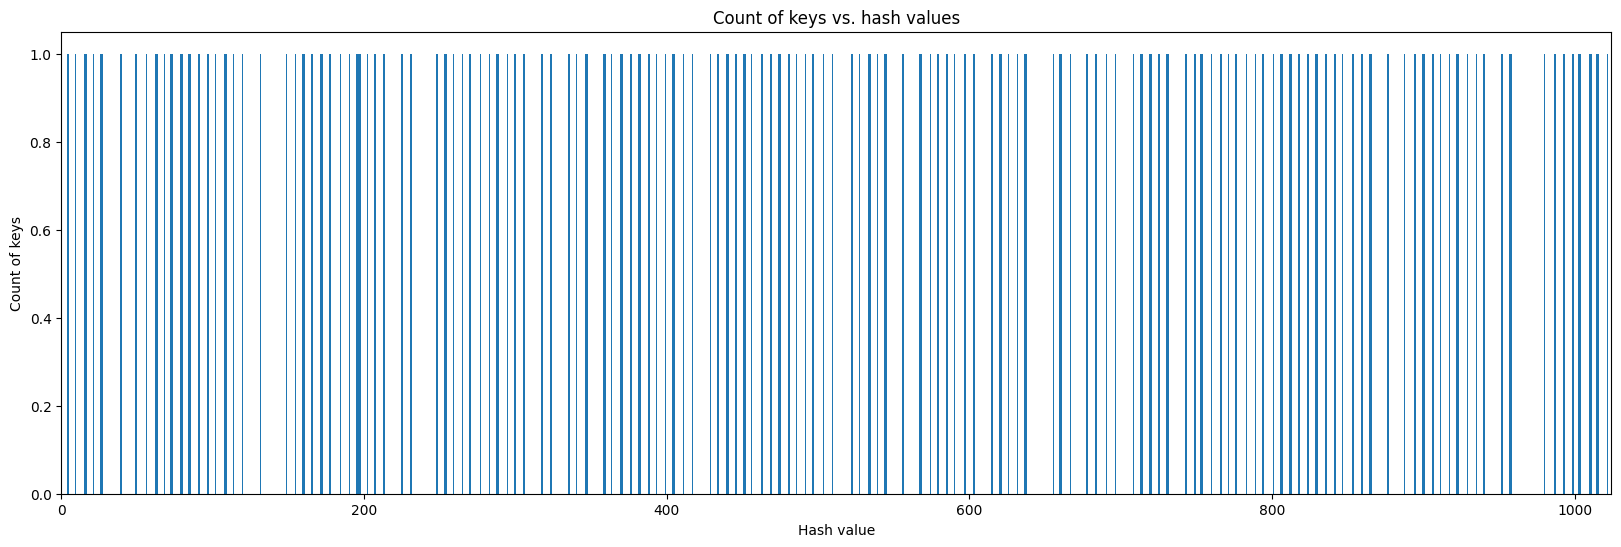

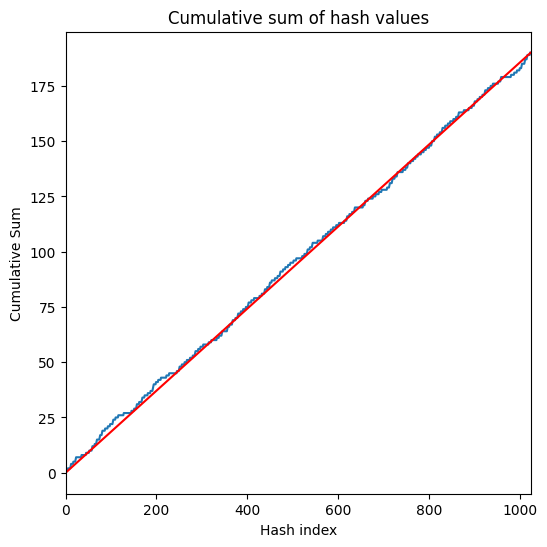

In [42]:
ls = []
for idx in range(len(hash_table)):
    if hash_table[idx] is not None: ls.append(idx) 

print(f"The number of buckets: {len(ls)}")
plot_hash(ls) 

> Examine these results and answer these questions:      
> 1. What evidence do you see that the hash collisions been resolved by the linear probing.
> 2. Has application of linear probing significantly affected the cumulative distribution function.         
> **End of exercise.**  

> **Answers:**    
> 1. The number of occupied buckets is 190, which matches the 190 key pairs. In the histogram, every occupied bucket has count 1, so the earlier duplicate hash buckets have been resolved by moving colliding entries to nearby empty buckets through linear probing.       
> 2. Linear probing has not significantly changed the cumulative distribution function, as it is still very close to the red line.            

## Adding Values to the Hash Buckets    

Now that hashing with linear probing has been implemented and a hash table instantiated with the keys, it is time to add the values to the table. At this point, the hash table only contains the keys, but no values. Specifically, you will add a tuple of the t-statistic and p-value for each of the k-v pairs already in the table. Recalling that the key has two values, you need to iterate over all the combinations of the random variable vectors (columns) to compute the pairwise statistics. The tuple of the keys and the tuple of the t-statistic and p-value update the contents of the hash bucket. The table now has complete k-v pairs for every combination of the variables being tested.         

There are two parts to the required processing. First, a function to update a bucket in the hash table given the linear probing is required. Second, you will need to compute the t-statistic and p-value and update the value of the appropriate bucket using the update function.

The `linear_prob_update` function follows a a pattern similar to the `linear_probing_insert` function you have already worked with. The flow of the function is as follows:
1. The bucket for the hashed key value is tested to see if the key is in that bucket. If so, the update is placed in the bucket.    
2. If the first bucket does not contain the required key, the linear probing starts by incrementing the hash by 1 in a while loop.
   - The loop continues until the key is found, or it is determined that the key is not present in the table.
   - If, within the loop, the new hash value is greater than the table length the hash value is set to 0, the beginning of the table. If the flag showing the table has started from the beginning already, the function returns `None` and prints a message, since the hash bucket does not exist. Otherwise, the flag is set to 1 and probing for key continues.    
3. Once the probing finds the required key the update is made to the hash table bucket and the hash table is returned.

> **Exercise 1-4:** Complete the code in the cell below to implement the algorithm described above. Then execute your code.       

In [43]:
def linear_prob_update(hash_value, key, value, hash_table):    
    """
    Function to update value of the key-value pairs into an existing hash table 

    Args
        hash_value - the hash index, int
        key - the key tuple of the bucket to update
        value - value tuple to add to hash tabel
        hash_table - hash table to update

    Returns: hash_table
    """
    #if key is in expected bucket
    if hash_table[hash_value] is not None and hash_table[hash_value][0] == key:
        hash_table[hash_value] = (key, value)
        return hash_table
    #if starting bucket is empty
    if hash_table[hash_value] is None:
        print("Key not found in hash table.")
        return None
    #otherwise, linear probing:
    hash_len = len(hash_table)
    flag = 0

    while True:
        hash_value += 1
        if hash_value >= hash_len:
            if flag == 1:
                print("Key not found in hash table.")
                return None
            hash_value = 0
            flag = 1
        if hash_table[hash_value] is None:
            print("Key not found in hash table.")
            return None
        if hash_table[hash_value][0] == key:
            hash_table[hash_value] = (key, value)
            return hash_table

## Now we are ready to update the values in the table    
for i,j in combinations(range(ncolumns), 2):
    t_statistic, p_value = ttest_ind(normal_vars[:,i], normal_vars[:,j])
    hash_value = multivariate_hash([i,j], a_s, b_s, p_s, modulo)
    linear_prob_update(hash_value, (i,j), (t_statistic, p_value), hash_table)

hash_table[:50]

[None,
 None,
 None,
 None,
 ((5, 10), (np.float64(-1.4743844506788977), np.float64(0.14053564956433443))),
 None,
 None,
 None,
 None,
 ((2, 9), (np.float64(-1.599624883959026), np.float64(0.109839928075064))),
 None,
 None,
 None,
 None,
 None,
 ((1, 2), (np.float64(0.4587033611154849), np.float64(0.6464970915550545))),
 ((9, 16), (np.float64(1.5540563610089477), np.float64(0.12032934843577578))),
 None,
 None,
 None,
 None,
 ((6, 15), (np.float64(-0.8128781695802666), np.float64(0.4163847595139216))),
 None,
 None,
 None,
 None,
 ((10, 16), (np.float64(1.3671605432775407), np.float64(0.17172877821284305))),
 ((5, 8), (np.float64(-0.5256379688600401), np.float64(0.5991981005371132))),
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 ((9, 14), (np.float64(0.9962217626754544), np.float64(0.31926304063169436))),
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 ((10, 14), (np.float64(0.8016549234384719), np.float64(0.422847925613104)))]

> You should be able to see the key-value pairs in some buckets of the hash table.   
> **End of exercise.**

## Querying the Hash Table

With the t-statistics and p-values computed, the next question to ask is how many of these 
How many of these t-tests will show **significance** at the 0.05 cut-off level? With 20 variables there are 190 unique pairwise combinations. We expect to find a number of falsely significant test results. This task can be accomplished by querying the table for all the key tuple pairs and applying a significance test to the p-value. The number of positive results is then summed.   

The `linear_prob_query` function follows a a pattern similar to the `linear_probing_update` function you have already worked with. The flow of this function is nearly identical to the foregoing functions you have already worked on. The only difference is that the function returns the value rather than the table.   

> **Exercise 1-5:** You will now complete and execute the code in the `test_significance` function below.

In [44]:
def linear_prob_query(hash_value, key, hash_table):    
    """
    Function to query the value of key-value pairs stored in a hash table 

    Args
        hash_value - the hash index, int
        key - the key tuple of the bucket to update
        hash_table - hash table to update

    Returns: The value of the key-value pair in the hash bucket
    """
    #if key is in expected bucket
    if hash_table[hash_value] is not None and hash_table[hash_value][0] == key:
        return hash_table[hash_value][1]
    #if starting bucket is empty
    if hash_table[hash_value] is None:
        print("Key not found in hash table.")
        return None
    #otherwise, linear probing:
    hash_len = len(hash_table)
    flag = 0

    while True:
        hash_value += 1
        if hash_value >= hash_len:
            if flag == 1:
                print("Key not found in hash table.")
                return None
            hash_value = 0
            flag = 1
        if hash_table[hash_value] is None:
            print("Key not found in hash table.")
            return None
        if hash_table[hash_value][0] == key:
            return hash_table[hash_value][1]

def test_significance(significance_level, test_function, hash_value, key, hash_table, q=1):    
    """
    Function to apply a significane test function to an hypothesis test  

    Dependencies:  
        linear_prob_query
        linear_prob_update

    Args
        significance_level - the cutoff value for the hypothsis test 
        test_function - a Python function used to determine if a test result is significant 
                       Arguments: 
                           significance_level
                           p-value 
                           q - parameter used for some test algorithms   
                       Regturns: logical, True or False
        hash_value - the hash index, int
        key - the key tuple of the bucket to update
        hash_table - hash table to update
        q - an optional parameter used for some significant test algorithms 
                       
    Returns: hash_table
    """
    
    # Query for the statistic values and apply a significance test    
    t_statistic, p_value = linear_prob_query(hash_value, key, hash_table)[:2]

    ## Call the significance test function 
    significant = call_function(test_function, **{'p_value': p_value, 'significance_level': significance_level})
    
    # Update the hash table   
    hash_table = linear_prob_update(hash_value, key, (t_statistic, p_value, significant), hash_table)
    return hash_table 

def call_function(func, **kwargs):
    ## Function to call the significance evaluation function 
    return func(**kwargs)


def standard_hypothesis_test(p_value, significance_level):
    ## Put your code below 
    if p_value <= significance_level: return True
    else: return False 


significance_level = 0.05 
for i,j in combinations(range(ncolumns), 2):
    hash_value = multivariate_hash([i,j], a_s, b_s, p_s, modulo)
    hash_table = test_significance(significance_level, standard_hypothesis_test, hash_value, (i,j), hash_table)
    
hash_table[:50]

[None,
 None,
 None,
 None,
 ((5, 10),
  (np.float64(-1.4743844506788977), np.float64(0.14053564956433443), False)),
 None,
 None,
 None,
 None,
 ((2, 9),
  (np.float64(-1.599624883959026), np.float64(0.109839928075064), False)),
 None,
 None,
 None,
 None,
 None,
 ((1, 2),
  (np.float64(0.4587033611154849), np.float64(0.6464970915550545), False)),
 ((9, 16),
  (np.float64(1.5540563610089477), np.float64(0.12032934843577578), False)),
 None,
 None,
 None,
 None,
 ((6, 15),
  (np.float64(-0.8128781695802666), np.float64(0.4163847595139216), False)),
 None,
 None,
 None,
 None,
 ((10, 16),
  (np.float64(1.3671605432775407), np.float64(0.17172877821284305), False)),
 ((5, 8),
  (np.float64(-0.5256379688600401), np.float64(0.5991981005371132), False)),
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 ((9, 14),
  (np.float64(0.9962217626754544), np.float64(0.31926304063169436), False)),
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 ((10, 14),
 

> 4. The code in the cell below sums the number of pairs found to be significant. Execute this code.  

In [45]:
def count_significant(hash_table):
    count = 0
    for i,j in combinations(range(ncolumns), 2):
        hash_value = multivariate_hash([i,j], a_s, b_s, p_s, modulo)
        count += linear_prob_query(hash_value, (i,j), hash_table)[2]
    return count    

print(f"Number of false discoveries: {count_significant(hash_table)}")

Number of false discoveries: 16


> Notice how the value tuples in the table have been updated.   
> **End of exercise.**

### Bonferroni correction  

Several adjustments to the multiple comparisons problem have been proposed. Dunn published a method know as the **Bonferroni correction** in 1961. The Bonferroni correction is a widely used method to reduce the false positive rate of hypothesis tests. The adjustment is simple:
$$\alpha_b = \frac{\alpha}{m} \\
with \\ 
m =\ number\ of\ groups$$

Can the Bonferroni correction help? In some cases, yes, by greatly increasing the confidence level required for a statistically significant result. The problem with the Bonferroni correction is the reduction in power as the confidence level becomes smaller. For big data problems with large numbers of variables, this issue can be especially serious. In fact, the Bonferroni correction can often lead to significant numbers of missed discoveries, or Type II errors. 

You will now apply the Bonferroni correction to determine the significance of the p-values of the pair-wise t-tests. execute the code in the cell below and examine the results.  

In [ ]:
significance_level = 0.05 

## Put your code below   
n = math.comb(ncolumns, 2)
q = significance_level / n

for i,j in combinations(range(ncolumns), 2):
    hash_value = multivariate_hash([i,j], a_s, b_s, p_s, modulo)
    hash_table = test_significance(q, standard_hypothesis_test, hash_value, (i,j), hash_table)
    
print(f"With Bonferonni cutoff value: {q}")
print(f"Number of false discoveries: {count_significant(hash_table)}")   

With Bonferonni cutoff value: 0.0002631578947368421
Number of false discoveries: 0


Notice the following results from applying the Bonferroni correction.   
1. The false positive rate has been reduced to zero.     
2. The Bonferroni significance cutoff is much smaller than the p-value resulting in a type II error in this case, resulting in a Type II error.    
3. While the Bonferroni correction reduces the FDR significantly, it does so at the cost of lowering the detection rate of significant differences.

## Another Dataset

To continue with the example, execute the code in the cell below to load the data and print the dimensionality of the data frame. 

In [47]:
gene_data = pd.read_csv('../data/ColonDiseaseGeneData-Cleaned.csv')
print(gene_data.shape)

(97, 10498)


There are data from 97 patients (rows) with 10,497 gene responses (features in columns). The specific problem we will explore is to determine which genes lead to expression of a certain disease. In this example, there are gene expression data for 97 patients. Some of these patients have ulcerative colitis, a condition believed not to be inheritable, and others have Crohn's disease, which is believed to be genetically inherited. One approach to this problem is to perform hypothesis tests on the expression each of the genes between patients with the two conditions. Since there are over 10,000 genes there is considerable chance for false discovery. Therefore, careful application of FDR control is required!

Execute the code in the cell below to view the first 5 columns of the data frame, which includes the expression of the first 4 genes.  

In [48]:
 print(gene_data.iloc[:,:5])      

              Disease State  FAM138F  LOC100133331  LOC100132062  LOC388312
0   Ulcerative Colitis (UC)   7.2980        8.5650        8.7778     9.2365
1   Ulcerative Colitis (UC)   8.0751        8.3536        8.7785     9.4256
2   Ulcerative Colitis (UC)   6.8458        8.8254        9.1960     9.8835
3   Ulcerative Colitis (UC)   7.6507        8.1838        8.2845     8.8011
4   Ulcerative Colitis (UC)   7.3524        8.4415        8.6630     9.1292
5   Ulcerative Colitis (UC)   7.2811        8.4023        8.6892     9.3487
6   Ulcerative Colitis (UC)   7.8913        8.8026        8.6892     8.4706
7   Ulcerative Colitis (UC)   7.0641        8.5498        8.7145     9.0538
8   Ulcerative Colitis (UC)   7.5266        8.8004        9.1334     9.8241
9   Ulcerative Colitis (UC)   7.0322        8.8119        9.1838     9.8496
10  Ulcerative Colitis (UC)   7.0657        8.6229        8.9592     9.5281
11  Ulcerative Colitis (UC)   7.5924        8.5463        9.1006     9.7927
12  Ulcerati

We need to perform two transformations of the gene response data before we can perform any analysis.    
1. Create two data frames, one for each patient condition.       
2. Take the transpose of the data frames so that the gene response vectors are in the rows.

Execute this code and examine the response.  

In [49]:
def map_gene(gene_data):  
    ## Function separates the columns by disease type  
    mask = gene_data.loc[:,'Disease State'] == 'Ulcerative Colitis (UC)'
    ulcerative = gene_data[mask]
    crohns = gene_data[np.logical_not(mask)]
    ## Return the transpose of the two data frame 
    return ulcerative.iloc[:,1:].transpose(), crohns.iloc[:,1:].transpose()
    
ulcerative, crohns = map_gene(gene_data)    
print(f"\nUlcerative Colitis data frame of dimension: {ulcerative.shape}")
print(ulcerative.iloc[:10,:10])
print(f"\nCorhn's data frame of dimension: {crohns.shape}")
print(crohns.iloc[:10,:10])


Ulcerative Colitis data frame of dimension: (10497, 24)
                    0        1        2        3       4        5       6  \
FAM138F        7.2980   8.0751   6.8458   7.6507  7.3524   7.2811  7.8913   
LOC100133331   8.5650   8.3536   8.8254   8.1838  8.4415   8.4023  8.8026   
LOC100132062   8.7778   8.7785   9.1960   8.2845  8.6630   8.6892  8.6892   
LOC388312      9.2365   9.4256   9.8835   8.8011  9.1292   9.3487  8.4706   
BC016143       7.3570   7.4431   7.5415   7.7199  7.4482   7.4577  8.6198   
BC071797       9.3514   8.3866   9.3600   8.1049  8.5243   9.1962  8.2408   
AX746564       6.6567   6.6723   6.7597   6.8368  6.3970   6.6616  7.3675   
LINC00623      9.5255   9.3573   9.5154   8.5869  9.1107   9.1972  8.6013   
FAM45B        10.3131  10.0814  10.4536  10.7979  9.8107  10.1680  9.5525   
DUX4           8.6933   9.0416   8.5655   9.2985  8.3710   9.4132  8.9020   

                   7        8        9  
FAM138F       7.0641   7.5266   7.0322  
LOC100133331 

You can see that there are 10,496 gene expression values for each of the 24 Corhn's patients and 73 colitis patients.  

### Simple significance test on gene response data

You will now apply both a standard hypothesis test and the static Bonferonni corrected hypothesis test to the gene expressions for the two patient populations. As a first step, execute the code in the cell below to compute a key-value pair table with the following content:    
- The keys are the gene identifiers
- The values are columns containing the t-statistic, the p-value, and a logical value of significance for the t-test on the gene.

In the interest of simplicity we are using a standard data frame as our k-v pair hash table. Data frames do in fact use a hash of the row and column indices to perform operations on the table. In this case, we will iterate though a key list to perform row-wise operations on the table.   

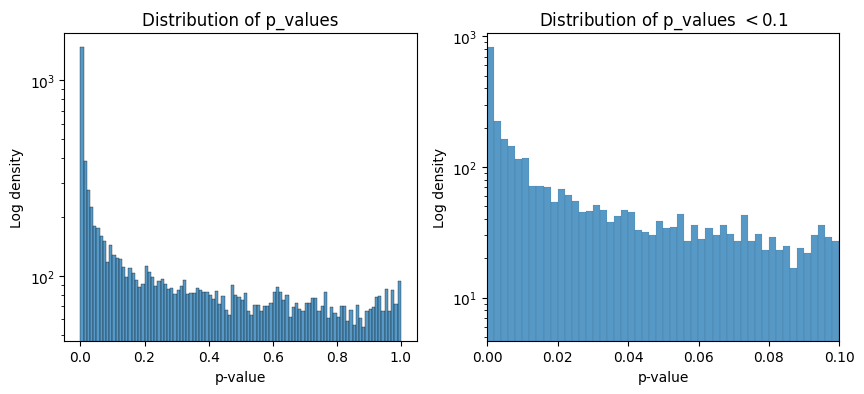

In [50]:
def plot_p_values(results):
    """
    Function to plot the distribution of p-values
    """
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(x='p_value', data=results, bins=100, ax=ax[0])
    ax[0].set_yscale('log')
    ax[0].set_title('Distribution of p_values')
    ax[0].set_xlabel('p-value')
    ax[0].set_ylabel('Log density')
    
    sns.histplot(x='p_value', data=results, bins=500, ax=ax[1])
    ax[1].set_yscale('log')
    ax[1].set_xlim(0, 0.1)
    ax[1].set_title(r'Distribution of p_values $< 0.1$')
    ax[1].set_xlabel('p-value')
    ax[1].set_ylabel('Log density')

def gene_t_test(corhns, ulcerative, keys):   
    '''
    Function to scan the tables of gene expression for the two patient populations and perform gene wise t-tests.   

    Args: 
        crohns - data frame of gene responses for Corhn's disease patients with rows keyed by gene identifier. 
        ulcerative - data frame of gene responses for ulerative cholitis patients with rows keyed by gene identifier.
        keys - a list or array of gene key values as strings   
    Returns: 
        A data frame with gene identifier as row key and with the following columns:  
        t_statistic 
        p_value
    '''
    t_test = pd.DataFrame(columns = ['t_statistic', 'p_value', 'significant'], index = keys)
    for key in keys: 
        t_statistic, p_value = ttest_ind(corhns.loc[key,:], ulcerative.loc[key,:])
        t_test.loc[key,:] = [t_statistic, p_value, None]

    return t_test    


# Get a list of the key values
key_list = crohns.index

t_test_results = gene_t_test(crohns, ulcerative, key_list)
plot_p_values(t_test_results)

From these plots one can see that there are a large number small of p-values. This situation is likely to result in high false discovery rate.   

You will now apply the standard hypothesis test method with a fixed significance level and no false discovery rate control to the gene expression dataset, as a basis of comparison. The function applies cutoff threshold or `significance_level` to the p-value and returns a logical, $\{True,False \}$. Execute the code in the cell below.  

In [51]:
def test_gene_significance(p_value, cutoff): 
    ## Put your code below 
    if p_value <= cutoff: return True
    else: return False 

significance_level = 0.05 
for key in key_list:
    t_test_results.loc[key,'significant'] = test_gene_significance(t_test_results.loc[key,'p_value'], significance_level)

print(f"Number of significant tests: {sum(t_test_results.loc[:,'significant'])}")

Number of significant tests: 2548


### Bonferonni significance test on gene response
With the basic test completed, you will now apply false discovery rate control with the Bonforonni method. Execute the code in the cell below with the static cutoff value or `significance_level` computed using the cutoff value and number of tests.    

In [52]:
cutoff = 0.05

## Put your code below
n_tests = len(crohns) 
significance_level = cutoff / n_tests

for key in key_list:
    t_test_results.loc[key,'significant'] = test_gene_significance(t_test_results.loc[key,'p_value'], significance_level)

print(f"Bonferonni cutoff level for significance: {significance_level}")
print(f"Number of Bonferonni significant tests: {sum(t_test_results.loc[:,'significant'])}")

Bonferonni cutoff level for significance: 4.763265694960465e-06
Number of Bonferonni significant tests: 59


Notice the following about these results.    
1. The expected number of false discoveries is approximately $0.05 \times 10000 = 500$ meaning a high number of false discoveries is expected.
2. The Bonforonni cutoff is 4 orders of magnitude lower than the standard cutoff and applied in a static manner, likely leaving missed discoveries.
3. For both methods the cutoff applied is static and the tests are computed independently, so high levels of parallelization are possible.  

## Improved False Discovery Rate Control Methods 

We have seen the potential pitfalls of multiple hypothesis testing. Further, we have seen that a simple Bonforonni approach to [**false discovery rate (FDR) control**](https://en.wikipedia.org/wiki/False_discovery_rate) is overly conservative may not be effective. You will now apply two more sophisticated FDR control methods, Holm's method and the Benjamini-Hochberg FDR control algorithm. These methods control the FDR, while not being overly conservative on true positive results, like the Bonferronic correction.        

These FDR control use the observation that p-values of the multiple hypothesis tests can be ordered. A dynamic threshold is applied to the ordered p-values to improve results compared to static methods like Bonforonni that use one threshold for all p-values. The dynamic threshold allows for both reduced false discovery rate while reducing the probability missed true discoveries.    

### Holm's method

The first of these **Holm's method**. Holm's method operates on the ordered set of p-values, $D = \{ p_{(1)}, p_{(2)}, p_{(3)}, \ldots, p_{(n)} \}$. The threshold is dynamic with the order of the P-value. For the $ith$ p-value, $p(i)$ for $N$ pairwise tests is:  

$$p(i) \le Threshold(Holm's) = \frac{\alpha}{N - i + 1}$$

For example: for the 10th ordered p-value with 1,000 total tests (genes) and significance level of 0.05, the cutoff is:   

$$p(10) \le \frac{0.05}{1000 - 10 + 1} = 0.00005045$$

You will now apply the dynamic Holm's FDR control method to the gene data. Do so by executing the code in the cell below, which executes the following steps:
1. The table sorted by p-value in ascending order.       
2. An updated key list is created from the ordered table.   
3. The Holm's significance levels are computed and appended to the `significance_levels` list.    
4. The significance tests are applied to the ordered p-values in the table.
5. The number of significant tests is computed and displayed.     

In [19]:
t_test_results.sort_values(by='p_value', ascending=True, inplace=True)
key_list = t_test_results.index

significance_level = 0.05 
significance_levels=[]

## Put your code below
for i in range(n_tests):
    significance_levels.append(significance_level/(n_tests - i + 2))

## The significance levels are added to the data frame 
t_test_results['significance_levels'] = significance_levels


for i, key in enumerate(key_list):
    t_test_results.loc[key,'significant'] = test_gene_significance(t_test_results.loc[key,'p_value'], significance_levels[i])

print(f"Number of Holm significant tests: {sum(t_test_results.loc[:,'significant'])}")

Number of Holm significant tests: 59


> With the results from the Holm's corrected significance test computed, execute the code in the cell below to display a graph summarizing these results.   

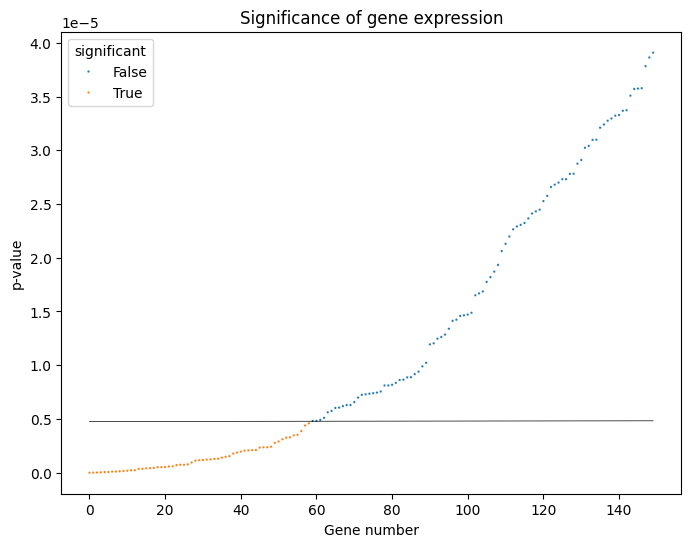

In [20]:
def plot_significance(results):
    results['test_number'] = range(len(results))
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.lineplot(x='test_number', y='significance_levels', data=results, ax=ax, color='black', linewidth=0.5)
    sns.scatterplot(x='test_number', y='p_value', hue='significant', data=results, s=3, ax=ax)
    ax.set_title('Significance of gene expression')
    ax.set_xlabel('Gene number')
    ax.set_ylabel('p-value')
    
plot_significance(t_test_results.iloc[:150,:].copy())    

Notice that for this particular dataset, the denominator of the Holm's correction is $N - i + 1$. With a large $N \sim 10000$ subtracting small values of i gives a cutoff nearly identical to the Bonforonni correction. In general, this will not be the case    

### Benjamini-Hochberg FDR Control 

The Benjamini-Hochberg FDR control algorithm is a more dynamic approach to false discovery control. Stat with an ordered set of $n$ p-values, $D = \{ p_{(1)}, p_{(2)}, p_{(3)}, \ldots, p_{(n)} \}$ we define a false discovery rate, $q$:

$$FDR(D) \le q$$

The cutoff threshold for the ith p-value is then:
$$p_{(i)} \le Threshold(D_q) = \frac{q}{n} i$$

You will apply the Benjamini-Hochberg FDR control algorithm for testing the significance of the gene expressions. The `BH_significance` function is quite similar to the Holm's method function you have already applied. Given the large number of genes you must use a low false discovery rate, $q = 0.001$, or 1 out of 1,000. Execute the code in the cell below that applies the following steps:   
1. Computes and appends the BH significance levels cutoff values to the `significance_levels` list.       
2. The significance tests are applied to the ordered p-values in the table.   
3. The number of significant tests is computed and displayed.    
4. Display a plot summarizing the BH test results.    

Number of Benjamini-Hochberg significant tests: 444


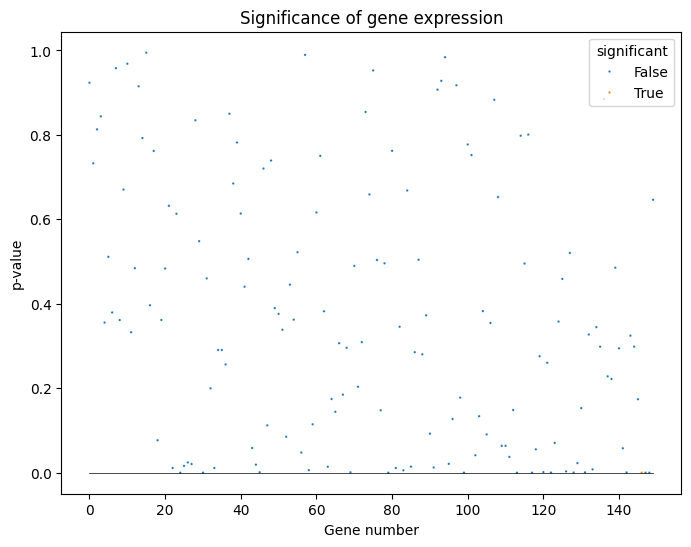

In [54]:
significance_level = 0.05 
q = 0.001
significance_levels=[]

## Put your code below  
for i in range(n_tests):
    significance_levels.append(q * (i + 1)/n_tests)

## Add the BH significance levels to the data frame
t_test_results['significance_levels'] = significance_levels


for i, key in enumerate(key_list):
    t_test_results.loc[key,'significant'] = test_gene_significance(t_test_results.loc[key,'p_value'], significance_levels[i])

print(f"Number of Benjamini-Hochberg significant tests: {sum(t_test_results.loc[:,'significant'])}")
plot_significance(t_test_results.iloc[:150,:].copy())  

Notice the following about the foregoing results. 
1. The threshold for the Benjamini-Hochberg FDR control method has the result index, $i$, in the numerator rather than in the denominator for Holm's method. This difference allows the Benjamini-Hochberg threshold to change more dynamically with the index (order) of the test result.    
2. Lowering the value of $q$ reduces the FDR, but at the expense of a higher probability of true discoveries.    

> **Note:** In practice, one should investigate using several values of $q$ for the BH FDR control algorithm to determine the effect of this parameter on the results. We will skip this step here in the interest of time.  

##### Copyright 2021, 2022, 2023, 2024, 2025, 2026 Stephen F. Elston. All rights reserved. 